# PRÁCTICA 4: DISTRIBUCIONES DE PROBABILIDAD

## Variables discretas

**Variable aleatoria** $X: S\to R$, del  espacio muestral a la recta real (como dominio de la función de probabilidad).

**Función de probabilidad** $P(x): R\to [0, 1]$, de la recta real al valor de la probabilidad. 

El Valor esperado es $E(X) = \sum_i p_ix_i$

In [ ]:
from scipy.integrate import quad # función para realizar integración numérica simple
from scipy.integrate import dblquad # integración doble.
import numpy as np 
import matplotlib.pyplot as plt

try:
    import seaborn as sns # Libreria para visualización de datos estadísticos.
except ImportError:
    !pip install seaborn
    import seaborn as sns
    
sns.set_style('ticks')

In [3]:
# Calculo del valor esperado de variables discreta
# entrada
x = [1, 2, 3, 4, 5]
p = [0.2, 0.2, 0.2, 0.2, 0.2]


parciales = 0 # o hacer: = sum(i * j for i, j in zip(x, p))
for i, j in zip(x, p):
    parciales += i * j # Multiplica el valor por su probabilidad y suma el resultado al total acumulado.

# Output
print('Valor esperado: {}'.format(parciales))

Valor esperado: 3.0


## Variable contínua

En Variables aleatorias contínuas: 
El valor esperado es  $E(X) = \int_{-\infty}^{\infty}xf(x)dx$

Ejemplo para ver cómo calcular integrales:
1. Dada la función cuadrática $f(x) = 1.5 - 6(x - 50)^2$, calcula la acumulación total (el área bajo la curva) en el intervalo que va desde $x = 49.5$ hasta $x = 50.5$

In [16]:
# CÁLCULO DEL ÁREA

func = lambda x: 1.5 - 6 * (x - 50) ** 2
domain = (49.5, 50.5)


cumulation = quad(func, domain[0], domain[1]) # quad: no devuelve un solo número, devuelve una tupla


print('Acumulación a partir de {} a {}: {:.6f} y error {}'.format(domain[0], domain[1], cumulation[0], cumulation[1])) #cumulation[1] es el error que en el siguiente ejemplo no lo pondremos.

Acumulación a partir de 49.5 a 50.5: 1.000000 y error 1.1102230246251553e-14


### Valor esperado y Varianza de variables aleatorias

Ejemplo para calcular la Esperanza

2. Sea $X$ una variable aleatoria continua con una función de densidad definida por $f(x) = \frac{2}{11}x$ en el intervalo $[5, 6]$. Encuentra el Valor Esperado $E[X]$ de esta distribución mediante integración numérica.

In [18]:
# EL VALOR ESPERADO

func = lambda x: x * (2/11)
domain = (5, 6)


def exp_func(x):
    return x * func(x)
exp = quad(exp_func, domain[0], domain[1])


print('Valor esperado: {:.6f}'.format(exp[0]))

Valor esperado: 5.515152


La varianza de variables aleatorias se define como

$$Var(X) = E(X-E(X))^2 = E(X^2) - E(X)^2$$

EJEMPLO PARA VARIABLES DISCRETAS

In [ ]:
# Calculo de la varianza y desviación típica para variables discretas

x = [1, 2, 3, 4, 5]
p = [0.2, 0.2, 0.2, 0.2, 0.2]

parciales1 = 0
parciales2 = 0
for i, j in zip(x, p):
    parciales1 += i * j
    parciales2 += i * i * j
var = parciales2 - parciales1 ** 2

print('Varianza: {:.4f}'.format(var))
print('Desviación estándard: {:.4f}'.format(var ** (1/2)))

Varianza: 2.0000
Desviación estándard: 1.4142


EJEMPLO PARA VARIABLES CONTINUAS

In [ ]:
# Calculo de la varianza y desviación típica para variables continuas. Es la misam formula pero con integrales en un dominio concreto.

func = lambda x: (2/11) * x
domain = (5, 6)


def exp_func(x):
    return x * func(x)
def exp_func2(x):
    return x * x * func(x)
exp = quad(exp_func, domain[0], domain[1])
exp2 = quad(exp_func2, domain[0], domain[1])
var = exp2[0] - exp[0] ** 2


print('Varianza: {:.4f}'.format(var))
print('Desviación estándard: {:.4f}'.format(var ** (1/2)))

Varianza: 0.0831
Desviación estándard: 0.2883


## Distribuciones de probabilidad

In [1]:
from scipy import stats

Una lista completa con las distribuciones continuas disponibles en el submódulo se encuentran en este [link](https://docs.scipy.org/doc/scipy/reference/stats.html#continuous-distributions). Ejemplos de estas son:

* Normal($\mu=5$, $\sigma^2=2$): ``stats.norm(loc=5, scale=2)``

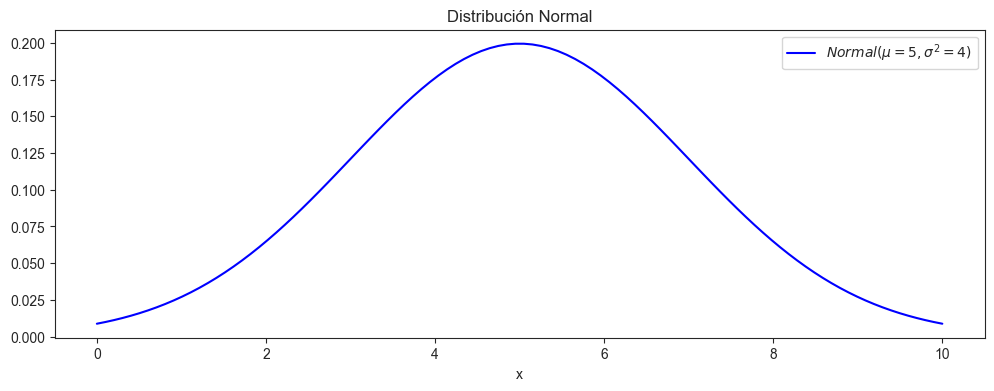

In [ ]:
# Instanciar Distribuciones
N = stats.norm(loc=5, scale=2) # distribución normal
# loc define la media
# scale define la desviación estándar

# Generar figura
plt.figure(figsize=(12,4))

# Generar puntos
x = np.linspace(0,10, 100)

# Generar probabilidades para la d.Normal 
plt.plot(x, N.pdf(x), "b", label="$Normal(\\mu=5, \\sigma^2=4)$") #pdf: Función de Densidad de Probabilidad


# Agregar estilo
plt.title("Distribución Normal")
plt.xlabel("x")
plt.legend()
plt.show()

Una lista completa con las distribuciones discretas disponibles en el submódulo se encuentran en este [link](https://docs.scipy.org/doc/scipy/reference/stats.html#discrete-distributions). Ejemplos de estas son:

* Bernoulli($p=0.3$): ``stats.bernoulli(p=0.3)``
* Poisson($\lambda=4$): ``stats.poisson(mu=4)``

Para Bernoulli un enunciado podría ser: Supongamos que en una línea de producción de componentes electrónicos, se sabe por estadística que el 30% de las piezas fabricadas presentan algún defecto de soldadura. Si seleccionamos una sola pieza al azar para inspeccionarla. Calcula y grafica la probabilidad de que la pieza sea defectuosa k=1 frente a la probabilidad de que esté en perfecto estado k= 0.

Para Poisson un enunciado podría ser: En la sala de urgencias de un hospital local, se ha registrado que llegan, en promedio, 4 pacientes por hora durante el turno de la madrugada. El director del hospital necesita entender la variabilidad de estas llegadas para asignar personal de enfermería. Calcula la probabilidad de que en una hora determinada lleguen exactamente 0, 1, 2, hasta 11 pacientes. Identifica visualmente cuál es el número de llegadas más probable (la moda de la distribución). Observa cómo disminuye la probabilidad a medida que nos alejamos del promedio de 4 pacientes.

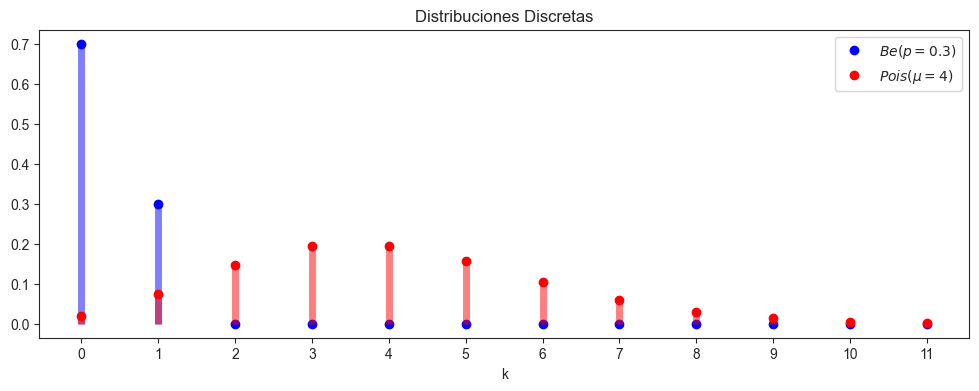

In [72]:
# Instanciar Distribuciones
Be = stats.bernoulli(p=0.3) # distribución de Bernoulli. p probabilidad de éxito.
Pois = stats.poisson(mu=4)  # distribución de Poisson. mu parámetro que indica el promedio.

# Generar figura
plt.figure(figsize=(12,4))

# Generar puntos 
k = np.arange(12) # genera números enteros

# Generar probabilidades para Bernoulli
Be1 = Be.pmf(k) # Función de Masa de Probabilidad.
plt.plot(k, Be1, "bo", label="$Be(p=0.3)$")
plt.vlines(k, 0, Be1, colors='b', lw=5, alpha=0.5)

# Generar probabilidades para Poisson
plt.plot(k, Pois.pmf(k), "ro", label="$Pois(\\mu=4)$")
plt.vlines(k, 0, Pois.pmf(k), colors='r', lw=5, alpha=0.5) # Dibuja líneas verticales desde el suelo (0) hasta el punto de probabilidad.

# Agregar estilo
plt.title("Distribuciones Discretas")
plt.xlabel("k")
plt.xticks(k) # Obliga a Matplotlib a mostrar todos los números del 0 al 11 en el eje X
plt.legend()
plt.show()

El módulo cuenta además otro tipo de distribuciones no paramétricas que generan una distribución a partir de una muestra empirica, a partir de datos aleatorios.

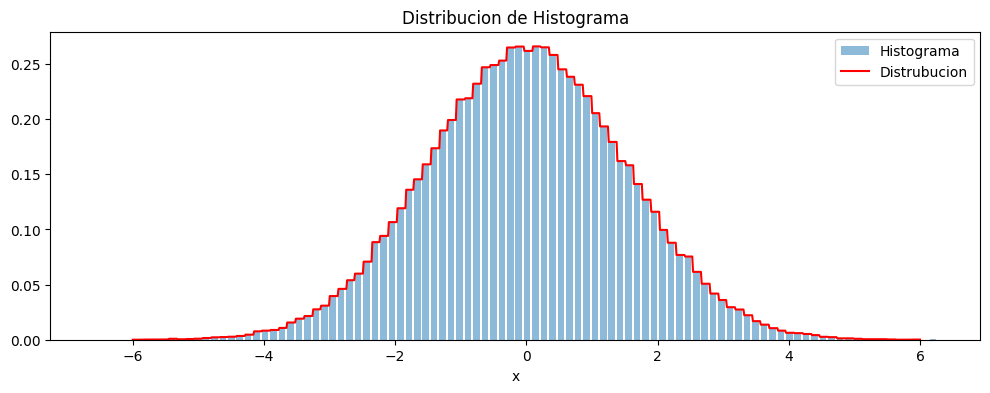

In [ ]:
# Generar datos
data = stats.norm.rvs(size=100000, loc=0, scale=1.5, random_state=123)

# Generar histogramas
bins = 100
hist = np.histogram(data, bins=bins)

# Generar distribucion
hist_dist = stats.rv_histogram(hist)

# Generar figura
plt.figure(figsize=(12,4))

# Graficar histograma
plt.hist(data, density=True, bins=bins, alpha=0.5,label="Histograma", width=0.1)

# Generar probabilidades
x = np.linspace(-6, 6, 1000)
plt.plot(x, hist_dist.pdf(x), "r-", label="Distrubucion") # Calcula la Función de Densidad de Probabilidad (PDF)

# Agregar estilo
plt.legend()
plt.title("Distribucion de Histograma")
plt.xlabel("x")
plt.show()

### Función de masa de probabilidad

Otra forma de representar las distribuciones ___discretas___ es utilizando su Función de masa de probabilidad que relaciona cada valor con su probabilidad

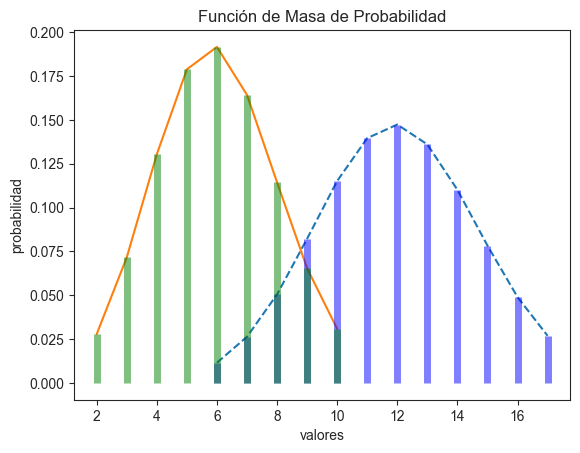

In [ ]:
n, p = 30, 0.4 # parametros de forma de la distribución binomial
n_1, p_1 = 20, 0.3 # parametros de forma de la distribución binomial
x = np.arange(stats.binom.ppf(0.01, n, p), # Percent Point Function(PPF). ¿Qué valor me da una probabilidad acumulada de p?
              stats.binom.ppf(0.99, n, p))
x_1 = np.arange(stats.binom.ppf(0.01, n_1, p_1),
              stats.binom.ppf(0.99, n_1, p_1))
fmp = stats.binom.pmf(x, n, p) # Función de Masa de Probabilidad
fmp_1 = stats.binom.pmf(x_1, n_1, p_1) # Función de Masa de Probabilidad
plt.plot(x, fmp, '--')
plt.plot(x_1, fmp_1)
plt.vlines(x, 0, fmp, colors='b', lw=5, alpha=0.5)
plt.vlines(x_1, 0, fmp_1, colors='g', lw=5, alpha=0.5)
plt.title('Función de Masa de Probabilidad')
plt.ylabel('probabilidad')
plt.xlabel('valores')
plt.show()

### Función de distribucion acumulada

Si queremos evitar los problemas que se generan con la función de densidad cuando el número de valores es muy grande, podemos recurrir a utilizar la Función de Distribución Acumulada, para representar las distribuciones, tanto discretas como continuas. Esta función relaciona los valores con su correspondiente percentil; es decir que va a describir la probabilidad de que una variable aleatoria X sujeta a cierta ley de distribución de probabilidad se sitúe en la zona de valores menores o iguales a x.

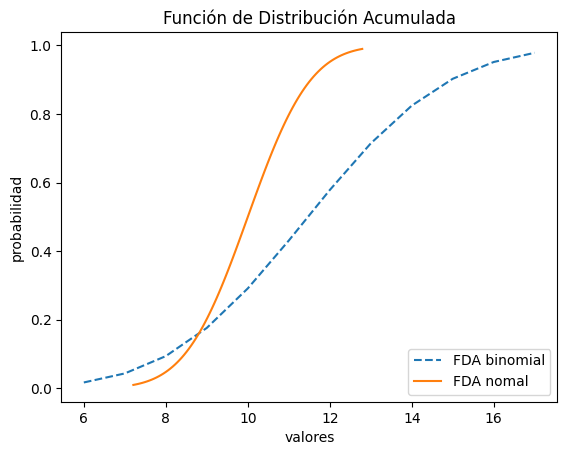

In [15]:
x_1 = np.linspace(stats.norm(10, 1.2).ppf(0.01),
                  stats.norm(10, 1.2).ppf(0.99), 100)
fda_binom = stats.binom.cdf(x, n, p) # Función de Distribución Acumulada
fda_normal = stats.norm(10, 1.2).cdf(x_1) # Función de Distribución Acumulada
plt.plot(x, fda_binom, '--', label='FDA binomial')
plt.plot(x_1, fda_normal, label='FDA nomal')
plt.title('Función de Distribución Acumulada')
plt.ylabel('probabilidad')
plt.xlabel('valores')
plt.legend(loc=4)
plt.show()

### Función de densidad de probabilidad

Por último, el equivalente a la funcion de masa de probabilídad pero aplicada a distribuciones ___continuas___ es la Función de Densidad de Probabilidad. Esta función es la derivada de la Función de Distribución Acumulada. Por ejemplo, para la distribución normal que graficamos anteriormente, su PDF (Función de Probabilidad) es la típica forma de campana que caracteriza a esta distribución.

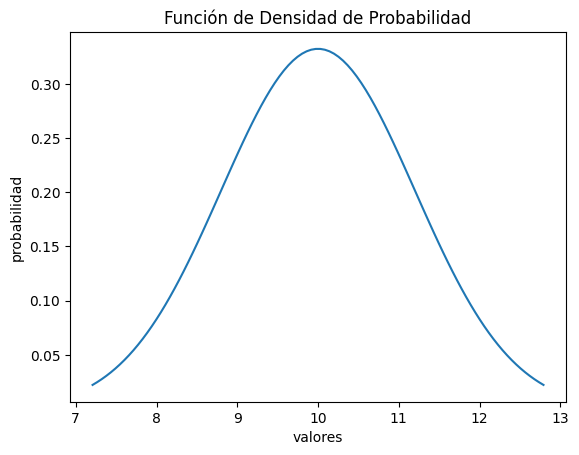

In [ ]:
FDP_normal = stats.norm(10, 1.2).pdf(x_1)
plt.plot(x_1, FDP_normal, label='FDP normal')
plt.title('Función de Densidad de Probabilidad')
plt.ylabel('probabilidad')
plt.xlabel('valores')
plt.show()

## Distribución discretas

Ahora que ya se conoce como representar las distribuciones, vamos a analizar cada una de ellas con más detalle para conocer su forma, sus principales aplicaciones y sus propiedades. Se empezará por las distribuciones discretas.

### Distribución geometrica

La Distribución Geométrica esta dada por la formula:

$$p(r; p) = p(1-p)^{r-1}$$

En dónde $r\geq 1$ y el parámetro es la probabilidad. La Distribución Geométrica expresa la probabilidad de tener que esperar exactamente $r$ pruebas hasta encontrar el primer éxito si la probabilidad de éxito en una sola prueba es $p$. Por ejemplo, en un proceso de selección, podría definir el número de entrevistas que deberíamos realizar antes de encontrar al primer candidato aceptable.

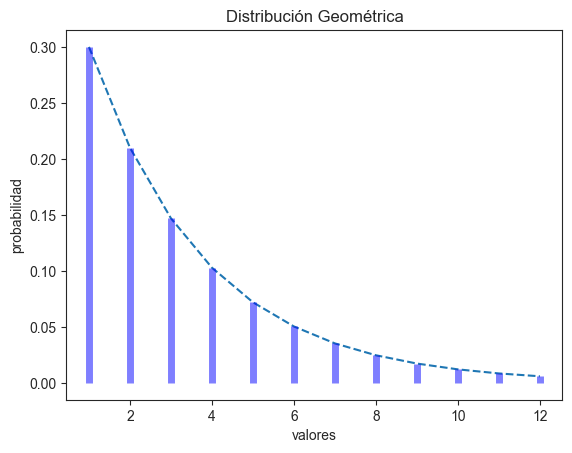

In [42]:
p =  0.3 # parametro de forma
geometrica = stats.geom(p) # Distribución
x = np.arange(geometrica.ppf(0.01),
              geometrica.ppf(0.99))
fmp = geometrica.pmf(x) # Función de Masa de Probabilidad
plt.plot(x, fmp, '--')
plt.vlines(x, 0, fmp, colors='b', lw=5, alpha=0.5)
plt.title('Distribución Geométrica')
plt.ylabel('probabilidad')
plt.xlabel('valores')
plt.show()

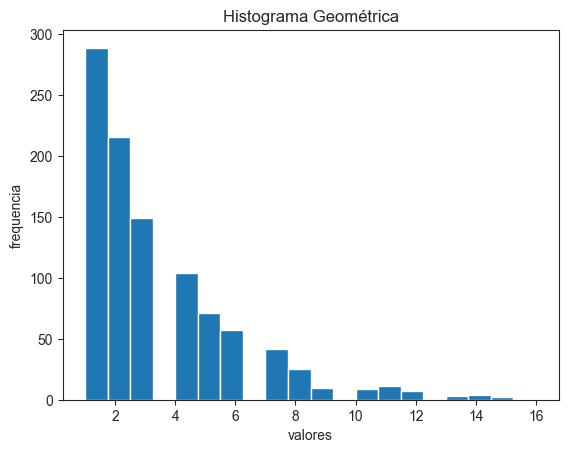

In [43]:
# histograma
aleatorios = geometrica.rvs(1000)  # genera aleatorios
cuenta, cajas, ignorar = plt.hist(aleatorios, 20)
plt.ylabel('frequencia')
plt.xlabel('valores')
plt.title('Histograma Geométrica')
plt.show()

### Distribución de Bernoulli

La Distribución de Bernoulli esta dada por la formula:

$$p(r; p) = \left\{ \begin{array}{lr} 1-p = q & \text{  si  } r= 0 \text{  (fracaso)} \\ p & \text{  si  } r = 1 \text{  (éxito)} \end{array} \right. $$

En dónde el parámetro $p$ es la probabilidad de éxito en un solo ensayo, la probabilidad de fracaso por lo tanto va a ser $1-p$ (muchas veces expresada como $q$). Tanto $p$ como $q$ son probabilidades luego están limitaaos al intervalo de cero a uno. La Distribución de Bernoulli describe un experimento probabilístico en donde el ensayo tiene dos posibles resultados, éxito o fracaso. Desde esta distribución se pueden deducir varias Funciones de Densidad de Probabilidad de otras distribuciones que se basen en una serie de ensayos independientes.

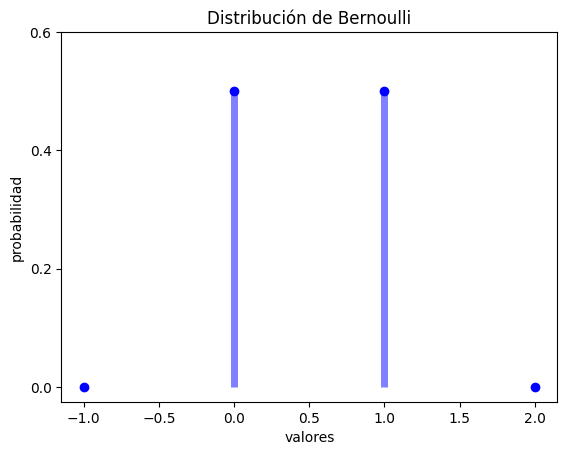

In [21]:
p =  0.5 # parametro de forma
bernoulli = stats.bernoulli(p)
x = np.arange(-1, 3)
fmp = bernoulli.pmf(x) # Función de Masa de Probabilidad
fig, ax = plt.subplots()
ax.plot(x, fmp, 'bo')
ax.vlines(x, 0, fmp, colors='b', lw=5, alpha=0.5)
ax.set_yticks([0., 0.2, 0.4, 0.6])
plt.title('Distribución de Bernoulli')
plt.ylabel('probabilidad')
plt.xlabel('valores')
plt.show()

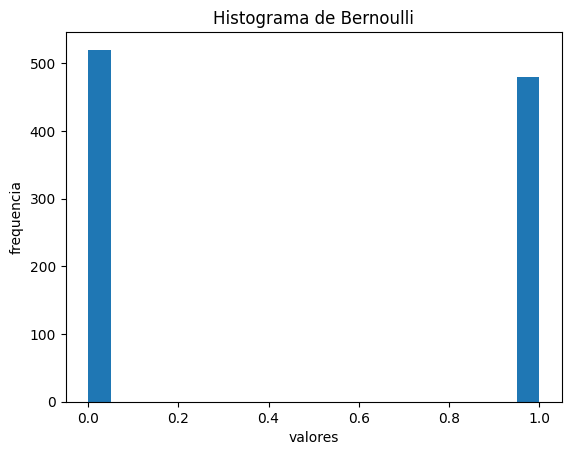

In [22]:
# histograma
aleatorios = bernoulli.rvs(1000)  # genera aleatorios
cuenta, cajas, ignorar = plt.hist(aleatorios, 20)
plt.ylabel('frequencia')
plt.xlabel('valores')
plt.title('Histograma de Bernoulli')
plt.show()

### Distribución Binomial 

La Distribución Binomial esta dada por la formula:

$$p(r; N, p) = {N \choose r} p^{r}(1-p)^{N-r}$$

En dónde $r$ con la condición $0 \leq r \leq N$ y el parámetro $N \geq 0$ son enteros; el parámetro $p$ es la probabilidad. La Distribución Binomial describe la probabilidad de exactamente $r$ éxitos en $N$ pruebas si la probabilidad de éxito en una sola prueba es $p$.

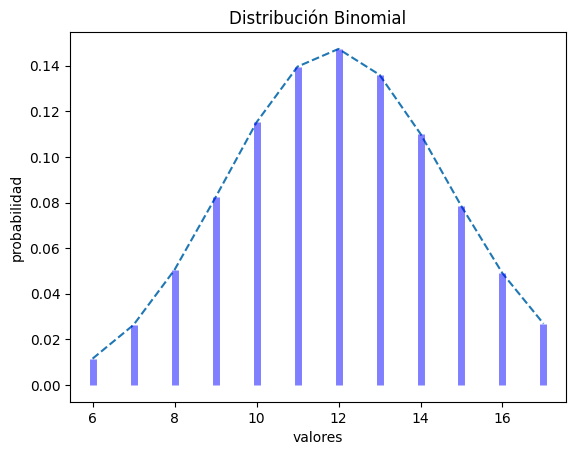

In [23]:
N, p = 30, 0.4 # parametros de forma
binomial = stats.binom(N, p) # Distribución
x = np.arange(binomial.ppf(0.01),
              binomial.ppf(0.99))
fmp = binomial.pmf(x) # Función de Masa de Probabilidad
plt.plot(x, fmp, '--')
plt.vlines(x, 0, fmp, colors='b', lw=5, alpha=0.5)
plt.title('Distribución Binomial')
plt.ylabel('probabilidad')
plt.xlabel('valores')
plt.show()

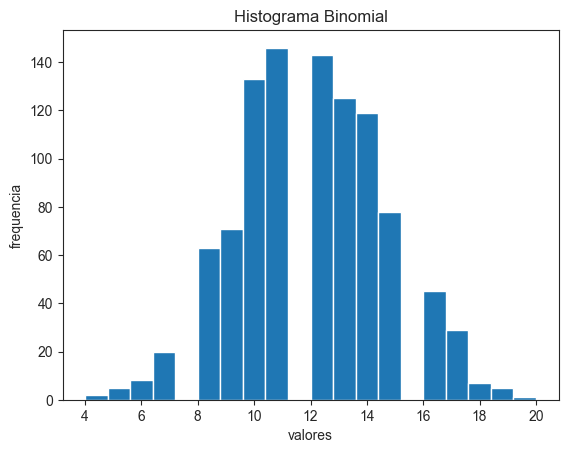

In [44]:
# histograma
aleatorios = binomial.rvs(1000)  # genera aleatorios
cuenta, cajas, ignorar = plt.hist(aleatorios, 20)
plt.ylabel('frequencia')
plt.xlabel('valores')
plt.title('Histograma Binomial')
plt.show()

#### Ejemplo

Sea una moneda equilibrada, es decir la probabilidad de salir cada uno de los lados es 0.5

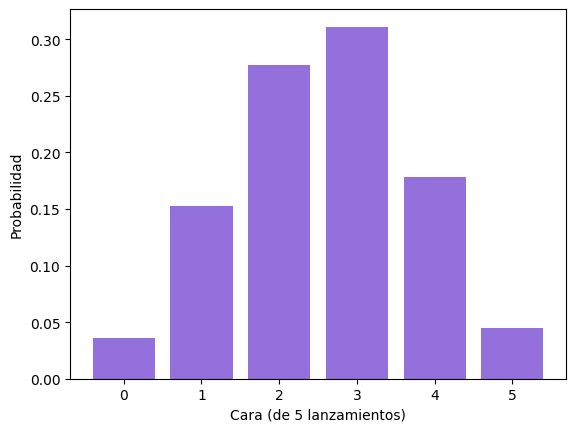

In [26]:
n = 5
n_experiments = 1000
heads_count = np.random.binomial(n, 0.5, n_experiments)
heads, event_count = np.unique(heads_count, return_counts=True)
event_proba = event_count/n_experiments

plt.bar(heads, event_proba, color='mediumpurple')
plt.xlabel('Cara (de 5 lanzamientos)')
_ = plt.ylabel('Probabilidad')

Ahora tenemos una moneda con pesos cuya probabilidad p = 0.8

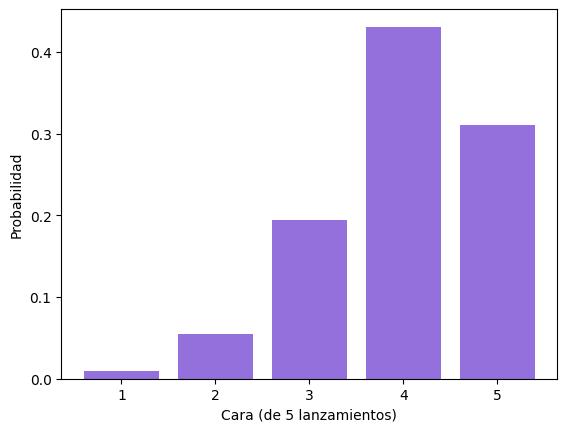

In [28]:
heads_count = np.random.binomial(n, 0.8, n_experiments)
heads, event_count = np.unique(heads_count, return_counts=True)
event_proba = event_count/n_experiments

plt.bar(heads, event_proba, color='mediumpurple')
plt.xlabel('Cara (de 5 lanzamientos)')
_ = plt.ylabel('Probabilidad')

Técnicamente, las distribuciones binomiales se crean muestreando $n>1$ «ensayos Bernoulli». La distribución **Bernoulli** es equivalente a la distribución binomial cuando $n=1$:

In [32]:
np.random.binomial(1, 0.5)

1

### Distribución de Poisson

**Poisson** es otra distribución ampliamente utilizada para variables aleatorias discretas. Viene dada por

$$p(r, \mu) = \frac{\mu^{r}e^{-r}}{r!}$$

En dónde $r$ es un entero ($\geq 0$) y $\mu$ es un número real positivo. La Distribución Poisson describe la probabilidad de encontrar exactamente $r$ eventos en un lapso de tiempo si los acontecimientos se producen de forma independiente a una velocidad constante $\mu$. Es una de las distribuciones más utilizadas en estadística con varias aplicaciones; como por ejemplo describir el número de fallos en un lote de materiales o la cantidad de llegadas por hora a un centro de servicios.

En Python la podemos generar fácilmente con la ayuda de scipy.stats, paquete que utilizaremos para representar a todas las restantes distribuciones a lo largo de todo el artículo.

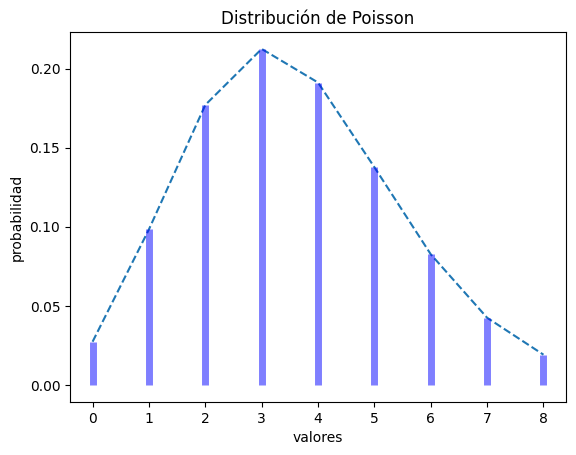

In [33]:
mu =  3.6 # parametro de forma
poisson = stats.poisson(mu) # Distribución
x = np.arange(poisson.ppf(0.01),
              poisson.ppf(0.99))
fmp = poisson.pmf(x) # Función de Masa de Probabilidad
plt.plot(x, fmp, '--')
plt.vlines(x, 0, fmp, colors='b', lw=5, alpha=0.5)
plt.title('Distribución de Poisson')
plt.ylabel('probabilidad')
plt.xlabel('valores')
plt.show()

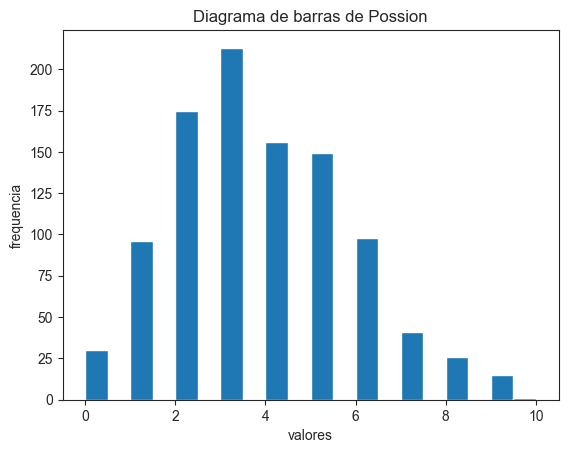

In [73]:
aleatorios = poisson.rvs(1000)  # genera aleatorios
cuenta, cajas, ignorar = plt.hist(aleatorios, 20)
plt.ylabel('frequencia')
plt.xlabel('valores')
plt.title('Diagrama de barras de Possion')
plt.show()

## Distribución contínuas

Ahora que ya conocemos las principales distribuciones discretas, podemos pasar a describir a las distribuciones continuas; en ellas a diferencia de lo que veíamos antes, la variable puede tomar cualquier valor dentro de un intervalo específico.


### Distribución normal

Carl Friedrich Gauss (matemático y científico alemán de principios del siglo XIX) da nombre a más de cien conceptos de matemáticas, física y astronomía. Uno de esos conceptos es la distribución de Gauss, también conocida como «curva de campana» (aunque varias distribuciones tienen forma de campana) o **distribución normal**. Esta distribución es aplicable a un amplio rango de problemas, lo que la convierte en la distribución más utilizada en estadística; está dada por la formula:

$$p(x; \mu, \sigma^{2}) = \frac{1}{\sigma \sqrt{2\pi}}e^{\frac{-1}{2}(\frac{x-\mu}{\sigma})^2}$$

En dónde $\mu$ es la media aritmética y $\sigma^2$ es la desviacion estándar. Algunos ejemplos de variables asociadas a fenómenos naturales que siguen el modelo de la Distribución Normal son: características morfológicas de individuos, como la estatura; características sociológicas, como el consumo de cierto producto por un mismo grupo de individuos; características psicológicas, como el cociente intelectual; nivel de ruido en telecomunicaciones; errores cometidos al medir ciertas magnitudes; etc.

La distribución normal tipificada tiene una media de cero y una desviación estándar de uno y se le denomina **distribución estandard nornal**. A la distribucion normal se le denota por $\mathcal{N}(\mu, \sigma^2)$, mientras que la distribución normal estandard es $\mathcal{N}(0, 1)$.

Las distribuciones normales son, con diferencia, las más comunes en estadística y aprendizaje automático. Suelen ser la opción por defecto, sobre todo si se dispone de información limitada sobre el proceso aleatorio que se está modelando, porque:

1. Las distribuciones normales asumen la mayor incertidumbre posible sobre la variable aleatoria que representan (en relación con cualquier otra distribución de varianza equivalente).

2. Tanto los procesos aleatorios simples como los muy complejos se distribuyen normalmente, en todas las condiciones habituales. Dado que muestreamos datos para modelos estadísticos y de aprendizaje automático por igual, este llamado **teorema del límite central** (que se trata a continuación) es un concepto de importancia crítica.

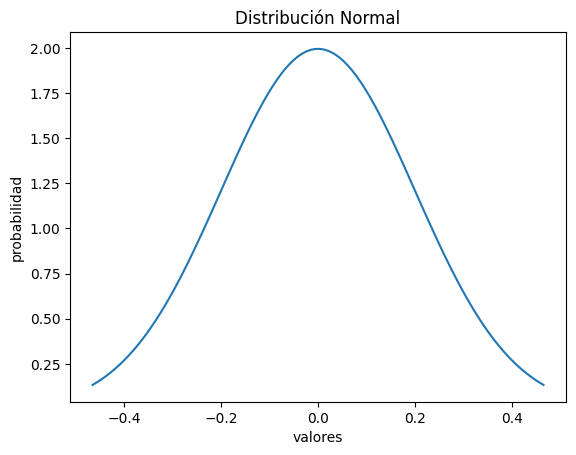

In [35]:
mu, sigma = 0, 0.2 # media y desvio estandar
normal = stats.norm(mu, sigma)
x = np.linspace(normal.ppf(0.01),
                normal.ppf(0.99), 100)
fp = normal.pdf(x) # Función de Probabilidad
plt.plot(x, fp)
plt.title('Distribución Normal')
plt.ylabel('probabilidad')
plt.xlabel('valores')
plt.show()

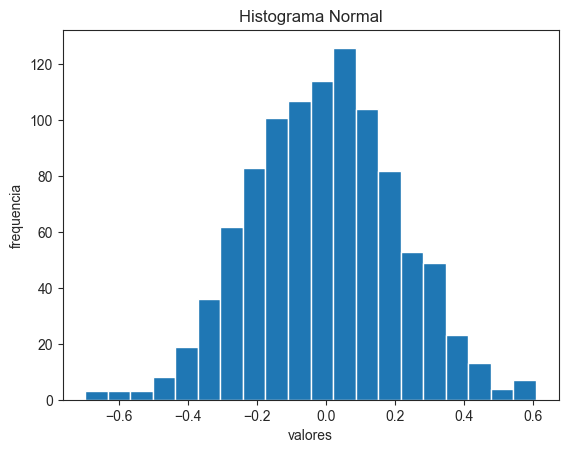

In [46]:
# histograma
aleatorios = normal.rvs(1000) # genera aleatorios
cuenta, cajas, ignorar = plt.hist(aleatorios, 20)
plt.ylabel('frequencia')
plt.xlabel('valores')
plt.title('Histograma Normal')
plt.show()

### TEOREMA LÍMITE CENTRAL

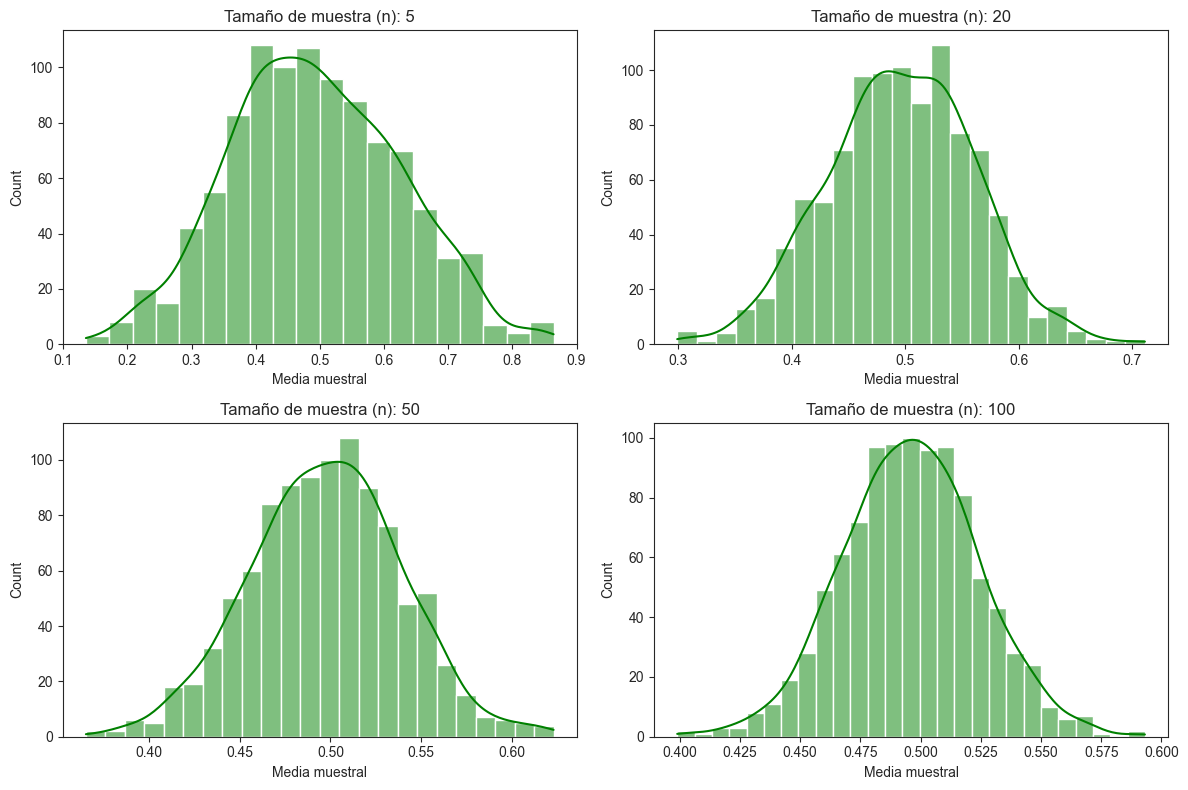

In [ ]:
# Creamos una distribución inicial "no normal" (ej. uniforme)
x = np.random.uniform(size=10000) 

def sample_mean_calculator(input_dist, sample_size, n_samples):
    sample_means = []
    for i in range(n_samples):
        # Tomamos una muestra aleatoria
        sample = np.random.choice(input_dist, size=sample_size, replace=False)
        # Calculamos la media de esa muestra y la guardamos
        sample_means.append(sample.mean())
    return sample_means

# 2. Configuración de la comparación
# Probaremos con tamaños de muestra crecientes para ver el TLC en acción
sample_sizes = [5, 20, 50, 100]
n_samples = 1000 # Un número alto de repeticiones para ver la forma de la curva

plt.figure(figsize=(12, 8))

for i, size in enumerate(sample_sizes):
    plt.subplot(2, 2, i+1)
    means = sample_mean_calculator(x, size, n_samples)
    
    # Dibujamos el histograma con la línea de densidad (KDE)
    sns.histplot(means, kde=True, color='green')
    plt.title(f'Tamaño de muestra (n): {size}')
    plt.xlabel('Media muestral')


plt.tight_layout()
plt.show()

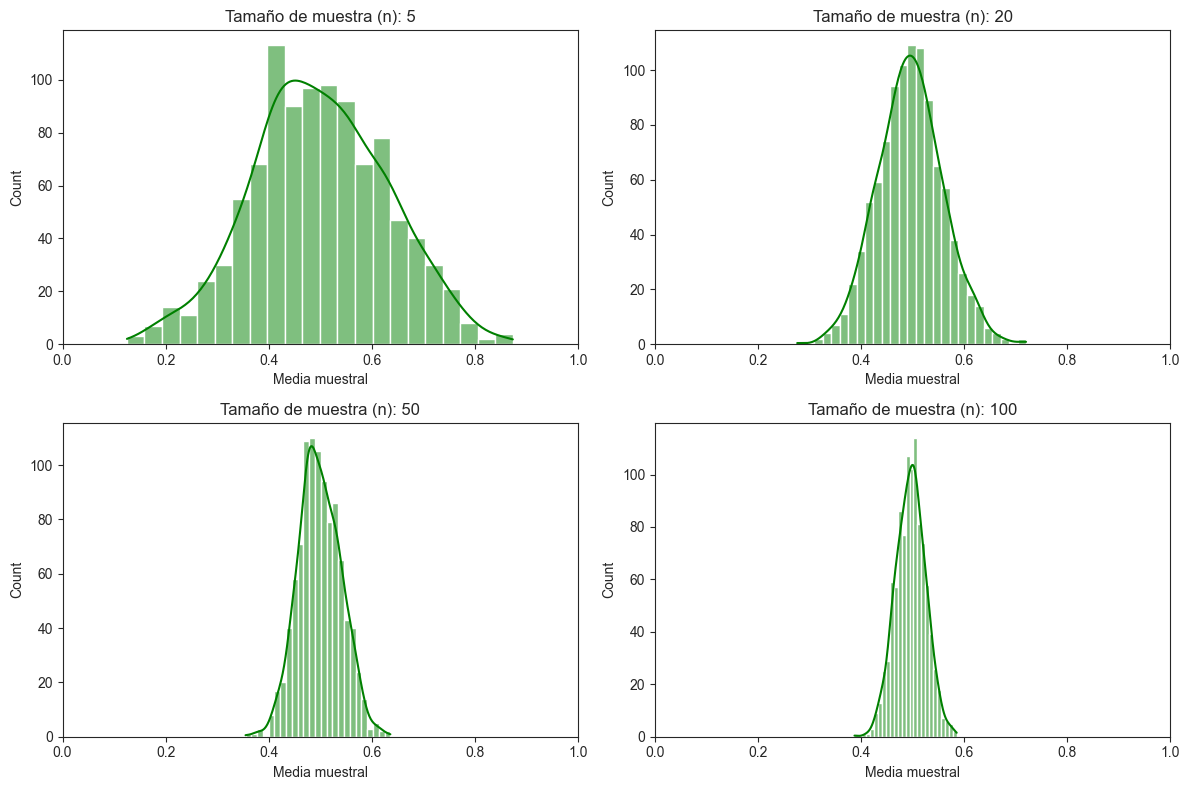

In [ ]:
# Creamos una distribución inicial "no normal" (ej. uniforme o exponencial)
x = np.random.uniform(size=10000) 

def sample_mean_calculator(input_dist, sample_size, n_samples):
    sample_means = []
    for i in range(n_samples):
        # Tomamos una muestra aleatoria
        sample = np.random.choice(input_dist, size=sample_size, replace=False)
        # Calculamos la media de esa muestra y la guardamos
        sample_means.append(sample.mean())
    return sample_means

# 2. Configuración de la comparación
# Probaremos con tamaños de muestra crecientes para ver el TLC en acción
sample_sizes = [5, 20, 50, 100]
n_samples = 1000 # Un número alto de repeticiones para ver la forma de la curva

plt.figure(figsize=(12, 8))

for i, size in enumerate(sample_sizes):
    plt.subplot(2, 2, i+1)
    means = sample_mean_calculator(x, size, n_samples)
    
    # Dibujamos el histograma con la línea de densidad (KDE)
    sns.histplot(means, kde=True, color='green')
    plt.title(f'Tamaño de muestra (n): {size}')
    plt.xlabel('Media muestral')
    plt.xlim(0, 1) # NUEVO RESPECTO ANTERIOR: ASÍ VISUALIZAMOS MEJOR LA CURVA NORMAL

plt.tight_layout()
plt.show()

## EJERCICIOS

1. En el lanzamiento de dos dados consideramos la variable aleatoria que asocia a cada resultado el mayor de los números obtenidos. Halla: 

    a) La función de probabilidad asociada a dicha variable aleatoria.

    b) La función de distribución asociada a dicha variable aleatoria.
    
    Crea una tabla para ambos apartados.

2. Hallar la media o valor esperado, varianza y desviación típica de la variable aleatoria del ejercicio anterior. Con 4 decimales.

3. Un jugador lanza tres monedas. Recibe 100 €, si salen tres caras; 25 €, si salen 2 caras; y nada, si sale cualquier otra combinación. ¿Cuál debería ser el precio de la apuesta para que el juego fuese equitativo o justo?

4. Se supone que la probabilidad de nacer niño es del 0,50. Calcula la probabilidad de que en una familia de seis hijos sean: 

    a) Todos varones. 

    b) Al menos, dos varones. 

    c) Tres varones.

    d) Calcula la media y la desviación típia.

5. Una prueba de inteligencia está compuesta por 10 preguntas, cada una de las cuales tiene cuatro respuestas, siendo sólo una de ellas correcta. Un alumno tiene prisa por acabar la prueba y decide contestar a lo loco, es decir, aleatoriamente. Se pide:

    a) Probabilidad de acertar exactamente cuatro preguntas.

    b) Probabilidad de no acertar ninguna pregunta.

    c) Probabilidad de acertar al menos 1.

    d)  Probabilidad de más de 3.

    e)  Probabilidad de acertar solo 2.

6. En el lanzamiento de tres dados, consideramos la variable aleatoria consistente en anotar el número de múltiplos de tres que aparecen. Responde a las siguientes cuestiones:   

    a)	Halla su función de probabilidad y represéntala.   


    b)	Determina su función de distribución y represéntala.


    c)	Halla la media y la desviación típica.

7. El 30% de un determinado pueblo ve un concurso que hay en televisión. Desde el concurso se llama por teléfono a 10 personas del pueblo elegidas al azar. Calcular la probabilidad de que, entre las 10 personas, estuvieran viendo el programa: 

    a) Más de ocho personas.

    b) Algunas de las diez personas. 

    c) Calcular la media y desviación típica.

8. Una sucursal bancaria de un pueblo pequeño atiende, en promedio, a 6 clientes por día.

    a) Definir una variable aleatoria que cuente el número de clientes por días e identificar la distribución de probabilidad que sigue esta variable aleatoria.

   b)  Calcular la probabilidad de que en un día dado, la sucursal atienda exactamente a 4 clientes. 

   c)  Calcular la probabilidad de que, en un día cualquiera, la sucursal atienda al menos a 6 clientes.

   d) Calcular la probabilidad de que, en un día dado, la sucursal reciba entre 6 y 8 clientes (ambos incluidos). 

   e) Generar una muestra de 10 valores aleatorios de la distribución y representala.

9. En unos estudios realizados sobre el peso de los estudiante de un colegio, se obtiene que el peso medio es 70 kg. y la desviación típica es 3 kg. Seleccionando un estudiante al azar y suponiendo que los pesos se distribuyen según una Normal, calcula:

    a) La probabilidad de que el estudiante pese entre 60 kg y 75 kg (ambos incluidos).

    b) La probabilidad de que el estudiante pese más de 62kg.

    c) La probabilidad de que el estudiante pese 64 kg.

    d) Peso mínimo del 10% más pesado.

    e) Doce pesos aleatorios que sigan dicha distribución.

10. Se ha estudiado el nivel de glucosa en sangre en ayunas en un grupo de diabéticos. Esta variable se supone que sigue una distribución Normal, con media 106 mg/ml y desviación típica 8 mg/ml.
Se  pide:

    a) Obtener la probabilidad de que el nivel de glucosa en sangre en un diabético sea inferior a 120 mg/ml.

    b) ¿Qué porcentaje de diabéticos tienen niveles de glucosa en sangre comprendidos entre 90 y 130 mg/ml?

    c) Hallar el valor de la variable caracterizado por la propiedad de que el 25% de todos los diabéticos tiene un nivel de glucosa en ayunas inferior a dicho valor.

    d) Generar una muestra de tamaño 12 para la una distribución Normal con media igual a 5 y desviación típica igual a la media.

11. Una fábrica produce bombillas cuya vida útil no es normal (muchas fallan pronto, pocas duran mucho).
Genera una población inicial x usando np.random.exponential(scale=1000, size=10000).
Crea una simulación para ver si la media de duración de un "lote" de 30 bombillas se aproxima a una normal, repitiendo el muestreo 500 veces.

12. Los tiempos de espera en un call center siguen una distribución uniforme entre 1 y 20 minutos.Utiliza lafunción para calcular la media de espera de 50 clientes elegidos al azar. Repite esto 2000 veces (n_samples) y grafica el resultado. ¿Cuál es el tiempo medio de espera que muestra el pico de tu campana de Gauss?

13. En un almacén, los pesos de los paquetes varían locamente entre 0.5kg y 50kg.Crea una distribución x con np.random.randint(low=1, high=50, size=5000). Compara en un solo plt.subplot qué sucede cuando el camión transporta solo 2 paquetes frente a cuando transporta 100 paquetes. Demuestra visualmente cuál es más "predecible".

14. El gasto de los clientes suele tener muchos valores bajos y algunos muy altos. Simula el gasto con x = np.random.pareto(a=2, size=10000) * 50. Implementa un bucle que pruebe sample_sizes = [10, 100, 1000]. ¿Cuántos datos por muestra se necesitan en este caso para que el histograma deje de verse "sesgado" y sea simétrico?